# CAZ Interactive Demo

*Run an LLM on your own concept pairs and watch CAZ emerge*

This notebook loads a language model and computes a full CAZ analysis on any concept you choose. Provide 10–20 contrastive sentence pairs and the notebook will show:
- Where in the model the concept crystallises (separation peak)
- Whether allocation is multimodal (two distinct assembly events)
- How your concept's peak depth compares to the 17 concepts from the paper

**Hardware requirements by model tier:**

| Tier | Models | VRAM | Notes |
|------|--------|------|-------|
| 1 — small | Qwen2.5-1.5B, GPT2-XL | ≤ 4 GB or CPU | **Default for ≤ 4 GB** — no quantization needed |
| 2 — medium | Qwen2.5-3B, Phi-2 | 4–8 GB | 4-bit quantized |
| 3 — paper | Qwen2.5-7B *(paper model)* | 8–16 GB | 4-bit, Colab T4 / Pro |
| 4 — large | Qwen2.5-14B, Llama-3.1-70B | 24+ GB | 4-bit, A100 / multi-GPU |

Your GPU is detected automatically and the best-fit model is pre-selected. **See § 1 to override.**

**[github.com/jamesrahenry/Rosetta](https://github.com/jamesrahenry/Rosetta)** · Henry (2026a)

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    _pip("rosetta_tools>=1.3.1")
except subprocess.CalledProcessError:
    _pip("rosetta_tools @ git+https://github.com/jamesrahenry/Rosetta_Tools.git@v1.3.1")

_pip("torch", "transformers", "accelerate", "huggingface_hub")

# bitsandbytes enables 4-bit quantization for Tier 2–4 models.
# Skip silently if installation fails (not needed for Tier 1 / CPU).
try:
    _pip("bitsandbytes")
except subprocess.CalledProcessError:
    print("bitsandbytes not installed — Tier 1 models (≤ 1.5 B) will still work fine.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import hf_hub_download

from rosetta_tools.extraction import extract_contrastive_activations
from rosetta_tools.caz import compute_layer_metrics, find_caz_regions

print("Imports OK.")

Imports OK.


In [3]:
from rosetta_tools.viz_style import (
    concept_color, CONCEPT_COLORS, FAMILY_COLORS, THEME, apply_theme,
)
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})
print("Style loaded.")

Style loaded.


In [4]:
from pathlib import Path
from collections import defaultdict
import urllib.request

_RCP_LOCAL  = Path.home() / "Source" / "Rosetta_Concept_Pairs" / "pairs" / "raw" / "v1"
_RCP_GITHUB = "https://raw.githubusercontent.com/jamesrahenry/Rosetta_Concept_Pairs/main/pairs/raw/v1"
_RCP_MODEL  = "claude-sonnet-4-6"   # preferred model for pair selection

def _load_rcp_jsonl(concept):
    """Load raw JSONL lines — local path first, GitHub fallback."""
    local = _RCP_LOCAL / f"{concept}_consensus_pairs.jsonl"
    if local.exists():
        with open(local) as f:
            return [json.loads(l) for l in f if l.strip()]
    url = f"{_RCP_GITHUB}/{concept}_consensus_pairs.jsonl"
    with urllib.request.urlopen(url) as r:
        return [json.loads(l) for l in r.read().decode().splitlines() if l.strip()]

def load_rcp_pairs(concept, n=12, model=_RCP_MODEL):
    """Return (pos_texts, neg_texts) of n pairs — one per topic, paragraphs."""
    lines = _load_rcp_jsonl(concept)
    by_topic = defaultdict(lambda: defaultdict(dict))
    for l in lines:
        by_topic[l['pair_id']][l['model_name']][l['label']] = l['text']
    pos_texts, neg_texts = [], []
    for pid, by_model in by_topic.items():
        # prefer specified model, fall back to any model that has both labels
        for m in ([model] + [k for k in by_model if k != model]):
            if 1 in by_model[m] and 0 in by_model[m]:
                pos_texts.append(by_model[m][1])
                neg_texts.append(by_model[m][0])
                break
        if len(pos_texts) >= n:
            break
    return pos_texts[:n], neg_texts[:n]

_rcp_ok = _RCP_LOCAL.exists()
print(f"RCP loader ready — {'local path found' if _rcp_ok else 'will use GitHub fallback'}")


RCP loader ready — local path found


In [5]:
# ── § 1  Model selection ─────────────────────────────────────────────────────
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 1e9
    print(f"GPU: {props.name}  |  VRAM: {vram_gb:.1f} GB")
else:
    vram_gb = 0
    print("No GPU detected — will run on CPU.")

# ─── Auto-recommendation ──────────────────────────────────────────────────────
if vram_gb >= 16:
    _rec = "Qwen/Qwen2.5-7B"
    _rec_tier = "Tier 3 — paper model; section 5 baseline matches exactly"
elif vram_gb >= 6:
    _rec = "Qwen/Qwen2.5-3B"
    _rec_tier = "Tier 2 — solid demo quality; 4-bit quantized"
elif vram_gb >= 2:
    _rec = "Qwen/Qwen2.5-1.5B"
    _rec_tier = "Tier 1 — fits in ≤ 4 GB VRAM; no quantization needed"
else:
    _rec = "openai-community/gpt2-xl"
    _rec_tier = "CPU fallback — no GPU or < 2 GB VRAM"

print(f"\nRecommended: {_rec}")
print(f"  {_rec_tier}")

# ─── Override here ────────────────────────────────────────────────────────────
# Uncomment any line below to use a different model, then re-run this cell.
#
# TIER 1 — CPU / ≤ 4 GB VRAM  (no quantization; bitsandbytes not required)
#   MODEL_ID = "Qwen/Qwen2.5-1.5B"           # 28L, 1536-dim, ~3 GB fp16  ← default ≤ 4 GB
#   MODEL_ID = "openai-community/gpt2-xl"     # 48L, 1600-dim, ~3 GB fp32  (CPU-friendly)
#   MODEL_ID = "openai-community/gpt2-large"  # 36L, 1280-dim, ~1.5 GB fp32
#   MODEL_ID = "EleutherAI/pythia-160m"       # 12L,  768-dim, < 1 GB      (fastest)
#   MODEL_ID = "Qwen/Qwen2.5-0.5B"           # 24L,  896-dim, ~1 GB
#
# TIER 2 — 4–8 GB VRAM  (4-bit quantized; requires bitsandbytes)
#   MODEL_ID = "Qwen/Qwen2.5-3B"             # 36L, 2048-dim, ~6 GB fp16 / ~2 GB 4-bit
#   MODEL_ID = "microsoft/phi-2"              # 32L, 2560-dim, ~5 GB fp16 / ~1.5 GB 4-bit
#   MODEL_ID = "EleutherAI/pythia-2.8b"      # 32L, 2560-dim, ~6 GB fp16 / ~2 GB 4-bit
#
# TIER 3 — 8–16 GB VRAM  (paper model; 4-bit on Colab T4 / Pro)   baseline ✓
#   MODEL_ID = "Qwen/Qwen2.5-7B"             # 28L, 3584-dim  ← PAPER MODEL
#   MODEL_ID = "meta-llama/Llama-3.1-8B"     # 32L, 4096-dim
#   MODEL_ID = "EleutherAI/pythia-6.9b"      # 32L, 4096-dim
#   MODEL_ID = "mistralai/Mistral-7B-v0.3"   # 32L, 4096-dim
#
# TIER 4 — 24+ GB VRAM  (A100 / multi-GPU)   baseline ✓
#   MODEL_ID = "Qwen/Qwen2.5-14B"            # 48L, 5120-dim
#   MODEL_ID = "Qwen/Qwen2.5-72B"            # 80L, 8192-dim
#   MODEL_ID = "meta-llama/Llama-3.1-70B"    # 80L, 8192-dim
# ─────────────────────────────────────────────────────────────────────────────

MODEL_ID = _rec  # ← change this line to override, e.g.  MODEL_ID = "Qwen/Qwen2.5-7B"

print(f"\nSelected: {MODEL_ID}")
print("Run § 2 to load the model.")

GPU: NVIDIA RTX 500 Ada Generation Laptop GPU  |  VRAM: 4.3 GB

Recommended: Qwen/Qwen2.5-1.5B
  Tier 1 — fits in ≤ 4 GB VRAM; no quantization needed

Selected: Qwen/Qwen2.5-1.5B
Run § 2 to load the model.


## 2. Load the model

The cell below loads the model selected in § 1. Loading strategy is chosen automatically:

- **Tier 1 (≤ 1.5 B):** fp16 on GPU, fp32 on CPU — `bitsandbytes` not required.
- **Tier 2–4 (3 B+):** 4-bit quantization via `bitsandbytes` to fit in GPU memory.

CAZ only needs `output_hidden_states=True`, which works identically on quantized models — quantization affects compute precision, not the geometric structure of the residual stream we measure.

*First download may take a few minutes. Subsequent runs use the cached weights.*

In [6]:
# Models that load in fp16/fp32 without 4-bit quantization
_TIER1 = {
    "openai-community/gpt2", "openai-community/gpt2-medium",
    "openai-community/gpt2-large", "openai-community/gpt2-xl",
    "EleutherAI/pythia-70m", "EleutherAI/pythia-160m", "EleutherAI/pythia-410m",
    "Qwen/Qwen2.5-0.5B", "Qwen/Qwen2.5-1.5B",
}

_use_quant = MODEL_ID not in _TIER1 and device == "cuda"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if _use_quant:
    from transformers import BitsAndBytesConfig
    _bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=_bnb, device_map="auto",
    )
else:
    _dtype = torch.float16 if device == "cuda" else torch.float32
    # No device_map for Tier 1 — avoids accelerate's memory planner which
    # emits "meta device" warnings even when the model fits comfortably.
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=_dtype)
    model = model.to(device)

model.eval()

n_layers = model.config.num_hidden_layers
print(f"Loaded: {MODEL_ID}")
print(f"  {n_layers} layers  |  {model.config.hidden_size}-dim hidden")
print(f"  Loading mode: {"4-bit quantized" if _use_quant else ("fp16" if device == "cuda" else "fp32 (CPU)")}")
if device == "cuda":
    used_gb = torch.cuda.memory_allocated(0) / 1e9
    print(f"  VRAM in use: {used_gb:.2f} GB")

Loaded: Qwen/Qwen2.5-1.5B
  28 layers  |  1536-dim hidden
  Loading mode: fp16
  VRAM in use: 3.09 GB


## 3. Choose your concept

Pairs are loaded from the **Rosetta Concept Pairs (RCP) dataset** — long-form paragraphs (~1 000 chars each) that express a concept through mechanism and context, *without* explicit connective keywords. This matters: see § 3b for a demo of what goes wrong with keyword-laden single sentences.

Five preset concepts are available; one is selected at random by default. **Set `PRESET = "..."` to pick a specific one**, or any other concept name in the RCP dataset (`agency`, `authorization`, `deception`, `exfiltration`, `formality`, `moral_valence`, `negation`, `plurality`, `specificity`, `temporal_order`, `threat_severity`, `urgency`).

In [7]:
import random as _rand
import html as _html_mod
from IPython.display import display, HTML as _HTML

_PRESETS = ["causation", "sentiment", "negation", "certainty", "sarcasm"]

# ── Select a concept ──────────────────────────────────────────────────────────
PRESET = "random"   # ← "causation" | "sentiment" | "negation" | "certainty" | "sarcasm"
                    #   or any concept name in the RCP dataset

if PRESET == "random":
    PRESET = _rand.choice(_PRESETS)
    print(f"Randomly selected: '{PRESET}'  (set PRESET = '...' to fix a concept)")
else:
    print(f"Using: '{PRESET}'")

# ── Load pairs from RCP ───────────────────────────────────────────────────────
CONCEPT_NAME = PRESET
pos_texts, neg_texts = load_rcp_pairs(CONCEPT_NAME, n=12)
assert len(pos_texts) == len(neg_texts)
avg_len = sum(len(p) for p in pos_texts) // len(pos_texts)
print(f"\nConcept: {CONCEPT_NAME!r}  —  {len(pos_texts)} RCP pairs  (~{avg_len} chars avg)")
print("Each pair: a matched paragraph — same topic, concept present vs absent.")

# ── Show pairs (selected concept open, others collapsed, first 3 shown each) ─
def _rcp_block(cname, selected):
    try:
        _p, _n = load_rcp_pairs(cname, n=3)
    except Exception as e:
        return (f'<details><summary style="font-family:sans-serif;font-size:13px;">'
                f'<strong>{_html_mod.escape(cname)}</strong>'
                f'&ensp;<span style="color:#aaa;font-size:11px;">unavailable</span>'
                f'</summary></details>')
    rows = "".join(
        '<tr>'
        f'<td style="padding:6px 10px;border-bottom:1px solid #eee;vertical-align:top;'
        f'width:50%;font-size:11.5px;line-height:1.4;">'
        f'{_html_mod.escape(p[:380])}{"…" if len(p) > 380 else ""}</td>'
        f'<td style="padding:6px 10px;border-bottom:1px solid #eee;vertical-align:top;'
        f'color:#555;width:50%;font-size:11.5px;line-height:1.4;">'
        f'{_html_mod.escape(n[:380])}{"…" if len(n) > 380 else ""}</td>'
        '</tr>'
        for p, n in zip(_p, _n)
    )
    open_attr = " open" if selected else ""
    bdr       = "#1565C0" if selected else "#ddd"
    badge     = (
        '&ensp;<span style="color:#1565C0;font-size:11px;">&#10003; selected — 12 pairs</span>'
        if selected else
        '&ensp;<span style="color:#aaa;font-size:11px;">3 of 12 shown</span>'
    )
    return (
        f'<details{open_attr} style="margin:3px 0;border:1px solid {bdr};'
        f'border-radius:4px;padding:0 8px;">'
        f'<summary style="cursor:pointer;padding:8px 4px;font-family:sans-serif;'
        f'font-size:13px;font-weight:600;">'
        f'{_html_mod.escape(cname)}{badge}</summary>'
        f'<table style="width:100%;border-collapse:collapse;margin:2px 0 10px;">'
        f'<thead><tr style="background:#f5f5f5;">'
        f'<th style="text-align:left;padding:5px 10px;font-weight:500;color:#333;'
        f'font-size:12px;font-family:sans-serif;">positive — concept present</th>'
        f'<th style="text-align:left;padding:5px 10px;font-weight:500;color:#777;'
        f'font-size:12px;font-family:sans-serif;">negative — same topic, concept absent</th>'
        f'</tr></thead><tbody>{rows}</tbody></table></details>'
    )

_display_concepts = _PRESETS if CONCEPT_NAME in _PRESETS else [CONCEPT_NAME] + _PRESETS
_blocks = "".join(_rcp_block(c, c == CONCEPT_NAME) for c in _display_concepts)
_intro = (
    '<p style="font-family:sans-serif;font-size:12px;color:#555;margin:0 0 8px;">'
    '<strong>RCP format:</strong> each row is one (pos, neg) paragraph pair on the same topic. '
    'Positive expresses the concept through mechanism; negative is the same topic with '
    'only co-occurrence — no concept signal. Showing first 3 of 12 pairs; expand to see them.</p>'
)
display(_HTML(f'<div style="margin:8px 0;">{_intro}{_blocks}</div>'))


Randomly selected: 'sarcasm'  (set PRESET = '...' to fix a concept)

Concept: 'sarcasm'  —  12 RCP pairs  (~1131 chars avg)
Each pair: a matched paragraph — same topic, concept present vs absent.


positive — concept present,"negative — same topic, concept absent"
"Deforestation directly causes increased flooding through a well-documented chain of ecological mechanisms. When trees are removed from a watershed, the soil loses its primary means of water absorption. Tree roots create channels in the soil that allow rainwater to percolate downward slowly, replenishing groundwater reserves. Without these roots, rainfall strikes compacted, expo…","Forests have been disappearing across many parts of the world for centuries. Logging companies operate in tropical regions, and timber is used in construction industries globally. Meanwhile, flooding events have been recorded throughout human history, affecting coastal cities, river valleys, and low-lying agricultural plains. In 2021, floods devastated parts of Germany and Belg…"
"Access to quality education directly drives economic mobility through a well-documented chain of mechanisms. When low-income students gain entry to well-resourced schools, they acquire both technical skills and social capital that employers specifically reward with higher wages. For example, a first-generation college student who attends a university with strong career placemen…","In 2019, Maria enrolled in a community college in Ohio. That same year, the state legislature approved a new budget. Tuition rates at public universities rose by three percent. Several technology companies announced expansions in nearby cities. Maria completed her associate degree in 2021. Unemployment figures fluctuated throughout that period. A report was published noting tha…"
"Sleep deprivation directly impairs cognitive function through a well-documented neurological cascade. When humans sleep fewer than seven hours per night, the brain's glymphatic system fails to adequately clear adenosine, a metabolic byproduct that accumulates during waking hours. This adenosine buildup progressively inhibits neural firing in the prefrontal cortex, the region re…",Many people report feeling foggy after a poor night's sleep. Researchers have published numerous studies examining sleep patterns in college students. Coffee consumption tends to be higher during exam periods. Hospital workers often describe their schedules as exhausting. Cognitive assessments appear in various psychological journals alongside articles about sleep. Some nights …
positive — concept present,"negative — same topic, concept absent"
"Last Saturday's dinner at Marigold Bistro was nothing short of magical. From the moment we stepped through the door, the warm amber lighting and soft jazz created an atmosphere that instantly melted away the week's stress. Our server, Marcus, greeted us with genuine enthusiasm and guided us through the menu with impressive knowledge, recommending the pan-seared halibut with lem…","Dinner at The Golden Fork last Friday was a dispiriting reminder of how badly a restaurant can mismanage every aspect of the dining experience simultaneously. We waited forty minutes past our reservation time before being seated, with no apology offered and no explanation given. The table itself wobbled noticeably, and the sticky laminated menus were an immediate red flag. Our …"
"The Nova X12 has completely transformed my daily routine, and I couldn't be more thrilled with this purchase. From the moment I unboxed it, the premium build quality was immediately apparent — the sleek titanium frame feels substantial yet surprisingly lightweight in hand. The 6.7-inch AMOLED display is nothing short of breathtaking, rendering colors with stunning accuracy and …","After two weeks with the Nova X12, I'm struggling to understand the hype surrounding this deeply disappointing device. The much-advertised titanium frame, while visually appealing, makes the phone uncomfortably slippery, and I've already dropped it twice despite being generally careful with my devices. That gorgeous display becomes a fingerprint magnet within minutes, requiring…"
"Our neighborhood has underg

## 3b. Why sentence pairs with explicit keywords give the wrong answer

The pairs above are 1 000-char paragraphs with no explicit concept-marker words. That's intentional. Here's what goes wrong with the simpler approach — single sentences that contain causal connectives like *"because"*, *"led to"*, *"caused"*:

| Pair type | What the model detects | Peak depth |
|-----------|----------------------|------------|
| `"X collapsed **because** Y corroded."` | Token "because" at embedding layer | ~3% |
| RCP paragraph (mechanism, context, no connectives) | Semantic causal structure | ~70% |

Run the cell below to see it live on your loaded model.

Running keyword-based sentence pairs...
  peak: 96.6%  (layer 28/28)  S=1.300
  unimodal

Running 5 RCP causation paragraph pairs...
  peak: 17.2%  (layer 5/28)  S=1.387
  unimodal


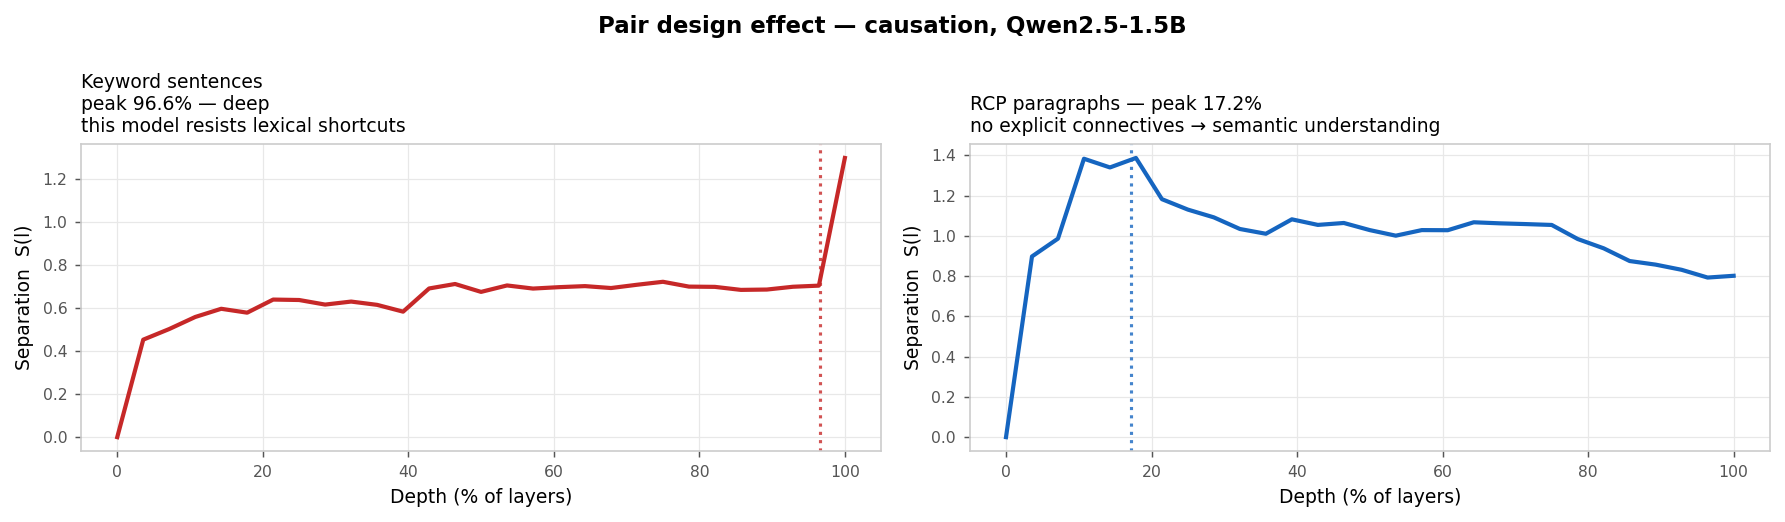


Gap: 79 pp between pair styles.
  79 pp gap suggests the keyword connectives bias the peak shallower.
  RCP paragraph pairs remove this confound.


In [8]:
# ── 5 keyword sentence pairs WITH explicit connectives ───────────────────────
_kw_pos = [
    "The bridge collapsed because the support beams had corroded.",
    "Scientists confirmed that the compound caused the cellular damage.",
    "Heavy rainfall led to widespread flooding across the valley.",
    "Chronic stress triggered the patient's recurring migraines.",
    "Poor early nutrition resulted in slower cognitive development.",
]
_kw_neg = [
    "The bridge collapsed, and the support beams were found to be corroded.",
    "Scientists observed the compound alongside the cellular damage.",
    "There was heavy rainfall, and the valley experienced widespread flooding.",
    "The patient had chronic stress and recurring migraines.",
    "The child had poor early nutrition and slower cognitive development.",
]

print("Running keyword-based sentence pairs...")
_kw_acts    = extract_contrastive_activations(model, tokenizer, _kw_pos, _kw_neg,
                                              device=device, batch_size=4)
_kw_metrics = compute_layer_metrics(_kw_acts)
_kw_profile = find_caz_regions(_kw_metrics)
_kw_peak    = _kw_profile.dominant.depth_pct
_kw_sep     = _kw_profile.dominant.peak_separation
print(f"  peak: {_kw_peak:.1f}%  (layer {_kw_profile.dominant.peak}/{n_layers})  S={_kw_sep:.3f}")
print(f"  {'multimodal' if _kw_profile.is_multimodal else 'unimodal'}")

# ── 5 RCP paragraph pairs ─────────────────────────────────────────────────────
print("\nRunning 5 RCP causation paragraph pairs...")
_rcp5_pos, _rcp5_neg = load_rcp_pairs("causation", n=5)
_rcp_acts    = extract_contrastive_activations(model, tokenizer, _rcp5_pos, _rcp5_neg,
                                               device=device, batch_size=2)
_rcp_metrics = compute_layer_metrics(_rcp_acts)
_rcp_profile = find_caz_regions(_rcp_metrics)
_rcp_peak    = _rcp_profile.dominant.depth_pct
_rcp_sep     = _rcp_profile.dominant.peak_separation
print(f"  peak: {_rcp_peak:.1f}%  (layer {_rcp_profile.dominant.peak}/{n_layers})  S={_rcp_sep:.3f}")
print(f"  {'multimodal' if _rcp_profile.is_multimodal else 'unimodal'}")

# ── Side-by-side separation profiles ─────────────────────────────────────────
_dp = [m.layer / n_layers * 100 for m in _kw_metrics]

def _kw_subtitle(peak):
    if peak < 25:
        return f"peak {peak:.1f}% — shallow lexical match\n\"because / caused\": detected before semantic layers"
    elif peak < 50:
        return f"peak {peak:.1f}% — mid-network\nsome shortcut signal likely"
    else:
        return f"peak {peak:.1f}% — deep\nthis model resists lexical shortcuts"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)
fig.patch.set_facecolor("white")
fig.suptitle(f"Pair design effect — causation, {MODEL_ID.split('/')[-1]}", fontsize=11, fontweight="bold")

for ax, metrics, profile, peak, color, title in [
    (ax1, _kw_metrics, _kw_profile, _kw_peak, "#C62828",
     f"Keyword sentences\n{_kw_subtitle(_kw_peak)}"),
    (ax2, _rcp_metrics, _rcp_profile, _rcp_peak, "#1565C0",
     f"RCP paragraphs — peak {_rcp_peak:.1f}%\nno explicit connectives → semantic understanding"),
]:
    vals = [m.separation for m in metrics]
    ax.plot(_dp, vals, color=color, lw=2)
    for region in profile.regions:
        ax.axvline(region.depth_pct, color=color, lw=1.5, ls=":", alpha=0.8)
    ax.set_xlabel("Depth (% of layers)", fontsize=9)
    ax.set_ylabel("Separation  S(l)", fontsize=9)
    ax.set_title(title, fontsize=9, loc="left")
    apply_theme(ax)

plt.tight_layout()
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────────
_gap = abs(_rcp_peak - _kw_peak)
print(f"\nGap: {_gap:.0f} pp between pair styles.")
if _kw_peak < 25:
    print("  Keyword pairs triggered a shallow lexical spike — the model found 'because'")
    print("  before processing meaning. RCP paragraphs push this into semantic territory.")
elif _gap > 15:
    print(f"  {_gap:.0f} pp gap suggests the keyword connectives bias the peak shallower.")
    print("  RCP paragraph pairs remove this confound.")
else:
    print(f"  Small gap ({_gap:.0f} pp) — this model handles keyword connectives robustly.")
    print("  RCP pairs still preferred: they measure concept understanding, not token co-occurrence.")

## 4. Extract activations and compute CAZ

This runs all sentences through every layer of the model and computes $S(l)$, $C(l)$, $v(l)$ at each layer. With 12 pairs: ~5–15 s on a small Tier 1 model, ~20–40 s on a T4 with a 7B model.

In [9]:
print("Extracting activations across all layers...")
layer_acts = extract_contrastive_activations(
    model, tokenizer, pos_texts, neg_texts,
    device=device, batch_size=4,
)

print("Computing CAZ metrics...")
metrics = compute_layer_metrics(layer_acts)
profile = find_caz_regions(metrics)
depth_pct = [m.layer / n_layers * 100 for m in metrics]

print(f"\nCAZ profile for '{CONCEPT_NAME}':")
print(f"  Allocation regions: {profile.n_regions}")
print(f"  Multimodal: {profile.is_multimodal}")
for i, region in enumerate(profile.regions):
    print(f"  Region {i+1}: peak layer {region.peak}  ({region.depth_pct:.1f}% depth)  "
          f"S={region.peak_separation:.3f}  C={region.peak_coherence:.3f}")

Extracting activations across all layers...
Computing CAZ metrics...

CAZ profile for 'sarcasm':
  Allocation regions: 1
  Multimodal: False
  Region 1: peak layer 7  (24.1% depth)  S=1.105  C=0.338


## 5. Visualise the allocation profile

The vertical dashed lines mark detected CAZ peaks. If there are two, the model is assembling the concept at two distinct depths — a shallow structural representation and a deeper semantic one.

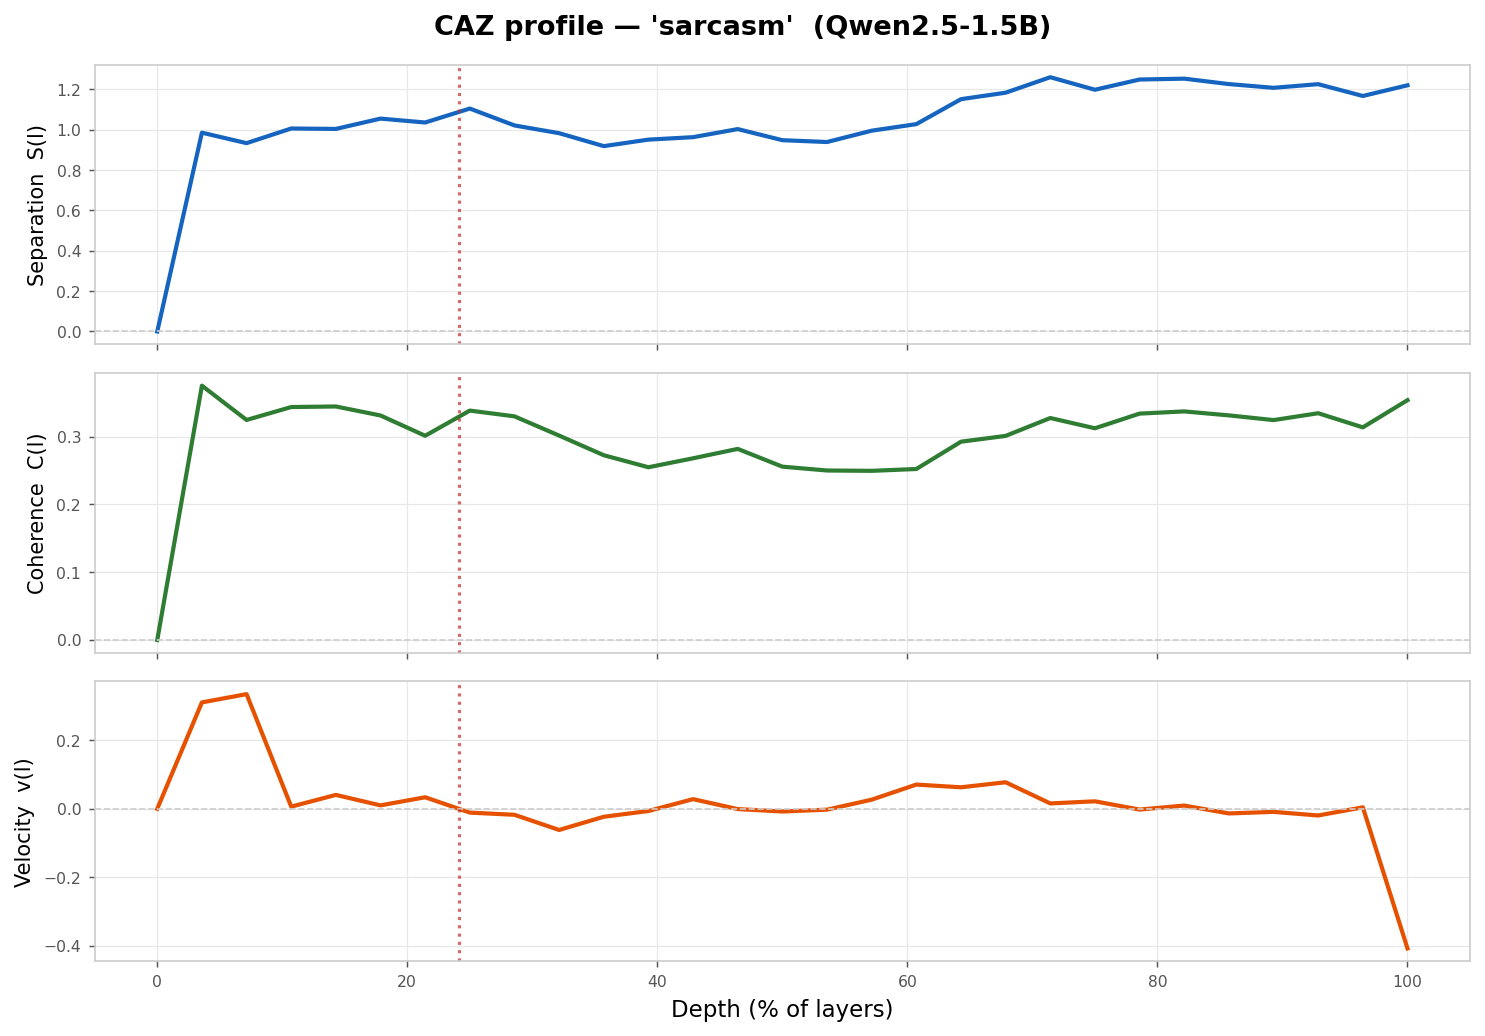

In [10]:
SIG_COLORS = {"separation": "#1565C0", "coherence": "#2E7D32", "velocity": "#E65100"}

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.patch.set_facecolor("white")
fig.suptitle(f"CAZ profile — '{CONCEPT_NAME}'  ({MODEL_ID.split('/')[-1]})",
             fontsize=13, fontweight="bold")

for ax, attr, ylabel, color in zip(
    axes,
    ["separation", "coherence", "velocity"],
    ["Separation  S(l)", "Coherence  C(l)", "Velocity  v(l)"],
    [SIG_COLORS["separation"], SIG_COLORS["coherence"], SIG_COLORS["velocity"]],
):
    vals = [getattr(m, attr) for m in metrics]
    ax.plot(depth_pct, vals, color=color, lw=2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.axhline(0, color=THEME["spine"], lw=0.8, ls="--")
    apply_theme(ax)
    for region in profile.regions:
        ax.axvline(region.depth_pct, color="#C62828", lw=1.5, ls=":", alpha=0.7)

axes[-1].set_xlabel("Depth (% of layers)", fontsize=11)
plt.tight_layout()
plt.show()

## 6. How does your concept compare?

The chart below shows your concept's peak depth against the 17-concept paper reference. Where available, the reference comes from the same model you're running; otherwise it falls back to the Qwen2.5-7B paper baseline.

**A note on pair count and signal quality:** CAZ peak location can shift by 10–20 pp with fewer than ~10 pairs, especially for subtle pragmatic concepts (sarcasm, urgency, credibility). The presets use 10 pairs, which is reliable for most concepts. If your peak looks implausibly shallow or deep, try adding 5–10 more well-matched pairs before drawing conclusions.

Loaded baselines for Qwen2.5-1.5B (17 concepts)


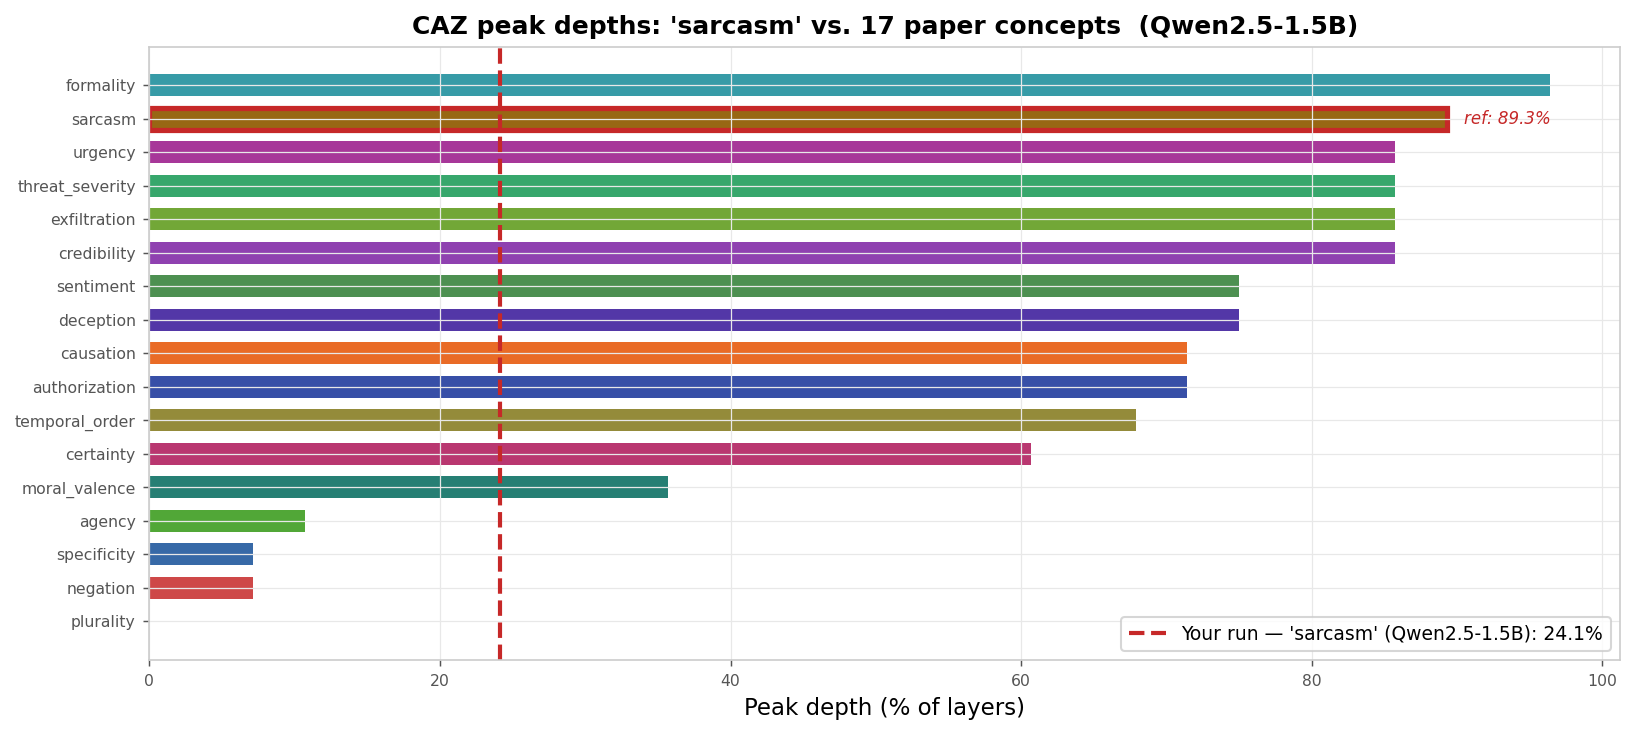

'sarcasm':
  Reference (Qwen2.5-1.5B): 89.3%
  Your run  (Qwen2.5-1.5B): 24.1%
  Note: 65 pp gap. Subtle concepts (sarcasm, urgency) need 15+ pairs
  for a stable peak — try adding more matched pairs to narrow this.


In [11]:
PAPER_CONCEPTS = [
    "agency", "authorization", "causation", "certainty", "credibility",
    "deception", "exfiltration", "formality", "moral_valence", "negation",
    "plurality", "sarcasm", "sentiment", "specificity", "temporal_order",
    "threat_severity", "urgency",
]

# Model key uses the same convention as rosetta_tools.gem:
#   model_id.replace("/", "_").replace("-", "_")
HF_REPO = "james-ra-henry/Rosetta-Activations"
# Paper data (N=250, frozen at paper-n250 tag). Switch to "models" when full RCP is available.
HF_DATA_ROOT = "paper_n250"
FALLBACK_KEY = "Qwen_Qwen2.5_7B"

def _model_key(mid):
    return mid.replace("/", "_").replace("-", "_")

# Try same-model baselines first, fall back to 7B
_mk = _model_key(MODEL_ID)
baseline = {}
_using_fallback = False
try:
    for c in PAPER_CONCEPTS:
        path = hf_hub_download(
            HF_REPO, filename=f"{HF_DATA_ROOT}/{_mk}/caz_{c}.json", repo_type="dataset",
        )
        with open(path) as f:
            baseline[c] = json.load(f)["layer_data"]["peak_depth_pct"]
    print(f"Loaded baselines for {MODEL_ID.split('/')[-1]} ({len(baseline)} concepts)")
except Exception:
    _using_fallback = True
    _mk = FALLBACK_KEY
    for c in PAPER_CONCEPTS:
        path = hf_hub_download(
            HF_REPO, filename=f"{HF_DATA_ROOT}/{_mk}/caz_{c}.json", repo_type="dataset",
        )
        with open(path) as f:
            baseline[c] = json.load(f)["layer_data"]["peak_depth_pct"]
    print(f"No same-model baseline found for {MODEL_ID.split('/')[-1]}; using Qwen2.5-7B reference.")
    print("  Tip: run with Qwen2.5-7B for an exact match.")

your_peak = profile.dominant.depth_pct
by_depth = sorted(baseline.items(), key=lambda x: x[1])
names_b = [c for c, _ in by_depth]
depths_b = [d for _, d in by_depth]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("white")

bar_colors = [concept_color(c) for c in names_b]
bars = ax.barh(names_b, depths_b, color=bar_colors, height=0.65, alpha=0.85)

# Highlight user's concept bar if it appears in the reference set
if CONCEPT_NAME in names_b:
    _idx = names_b.index(CONCEPT_NAME)
    bars[_idx].set_alpha(1.0)
    bars[_idx].set_edgecolor("#C62828")
    bars[_idx].set_linewidth(2.5)
    ax.text(
        depths_b[_idx] + 1.2, _idx,
        f"ref: {depths_b[_idx]:.1f}%",
        va="center", fontsize=8, color="#C62828", style="italic",
    )

# Always show your run as a vertical line
ax.axvline(
    your_peak, color="#C62828", lw=2, ls="--",
    label=f"Your run — '{CONCEPT_NAME}' ({MODEL_ID.split('/')[-1]}): {your_peak:.1f}%",
)
ax.legend(fontsize=9, loc="lower right")

ax.set_xlabel("Peak depth (% of layers)", fontsize=11)
_ref_label = MODEL_ID.split('/')[-1] if not _using_fallback else "Qwen2.5-7B reference"
ax.set_title(
    f"CAZ peak depths: '{CONCEPT_NAME}' vs. 17 paper concepts  ({_ref_label})",
    fontsize=12, fontweight="bold",
)
if _using_fallback:
    ax.set_xlabel(
        "Peak depth (% of layers)\n"
        "⚠  Reference bars are Qwen2.5-7B — absolute depths vary by model size",
        fontsize=10,
    )
apply_theme(ax)
plt.tight_layout()
plt.show()

if CONCEPT_NAME in baseline:
    ref_depth = baseline[CONCEPT_NAME]
    delta = abs(your_peak - ref_depth)
    print(f"'{CONCEPT_NAME}':")
    print(f"  Reference ({_ref_label}): {ref_depth:.1f}%")
    print(f"  Your run  ({MODEL_ID.split('/')[-1]}): {your_peak:.1f}%")
    if _using_fallback:
        print("  ⚠ Cross-model comparison — depth difference is expected.")
    elif delta > 15:
        print(f"  Note: {delta:.0f} pp gap. Subtle concepts (sarcasm, urgency) need 15+ pairs")
        print(f"  for a stable peak — try adding more matched pairs to narrow this.")
else:
    rank = sum(1 for d in depths_b if d < your_peak) + 1
    print(f"'{CONCEPT_NAME}' peaks at {your_peak:.1f}%  —  rank {rank} of {len(depths_b)+1} (shallow → deep)")
    if _using_fallback:
        print(f"  (Reference is Qwen2.5-7B; absolute depths differ on {MODEL_ID.split('/')[-1]}.)")

## 7. Batch concept sweep

Run a 10-pair probe across all 17 paper concepts to see the full CAZ landscape on this model. The chart includes a side-by-side comparison against the published Qwen2.5-7B results from the paper (Rosetta_Concept_Pairs dataset, 12–15 pairs/concept).

**Signal quality and pair count:** 4 pairs per concept gives a rough peak estimate; 10 pairs (used here) is stable for most concepts; 12–15 pairs (paper) gives publication-quality results. Pragmatic concepts like *sarcasm* and *urgency* are the most sensitive — the ordering tends to be preserved across pair counts, but the absolute depth can shift by up to ~15 pp.

In [12]:
# ── Load RCP pairs for all 17 paper concepts ─────────────────────────────────
_BATCH_CONCEPTS = [
    "agency", "authorization", "causation", "certainty", "credibility",
    "deception", "exfiltration", "formality", "moral_valence", "negation",
    "plurality", "sarcasm", "sentiment", "specificity", "temporal_order",
    "threat_severity", "urgency",
]
_N_PER_CONCEPT = 8   # RCP paragraphs are long; 8 pairs gives reliable signal

print("Loading RCP pairs...")
BATCH_PAIRS = {}
for _c in _BATCH_CONCEPTS:
    try:
        _pos, _neg = load_rcp_pairs(_c, n=_N_PER_CONCEPT)
        BATCH_PAIRS[_c] = (_pos, _neg)
    except Exception as _e:
        print(f"  Warning: {_c} — {_e}")
_total = len(BATCH_PAIRS) * _N_PER_CONCEPT
print(f"Loaded: {len(BATCH_PAIRS)} concepts × {_N_PER_CONCEPT} pairs = {_total} total sentence pairs\n")

# ── Run sweep ─────────────────────────────────────────────────────────────────
print(f"Running sweep on {MODEL_ID.split('/')[-1]}...")
print(f"  (RCP paragraphs are ~1000 chars each; allow ~2-3 min on a 4GB GPU)\n")
sweep_results = {}
for i, (cname, (pos, neg)) in enumerate(BATCH_PAIRS.items()):
    acts = extract_contrastive_activations(model, tokenizer, pos, neg,
                                          device=device, batch_size=2)
    m = compute_layer_metrics(acts)
    p = find_caz_regions(m)
    sweep_results[cname] = p
    peak = p.dominant.depth_pct
    mm   = "multimodal" if p.is_multimodal else "unimodal  "
    sep  = p.dominant.peak_separation
    print(f"  [{i+1:2d}/{len(BATCH_PAIRS)}] {cname:<20s}  peak {peak:5.1f}%  {mm}  S={sep:.3f}")

print(f"\nDone. {len(sweep_results)} concepts.")


Loading RCP pairs...
Loaded: 17 concepts × 8 pairs = 136 total sentence pairs

Running sweep on Qwen2.5-1.5B...
  (RCP paragraphs are ~1000 chars each; allow ~2-3 min on a 4GB GPU)

  [ 1/17] agency                peak  10.3%  multimodal  S=0.998
  [ 2/17] authorization         peak  20.7%  unimodal    S=1.055
  [ 3/17] causation             peak  10.3%  multimodal  S=1.183
  [ 4/17] certainty             peak  37.9%  multimodal  S=1.243
  [ 5/17] credibility           peak  75.9%  multimodal  S=1.840
  [ 6/17] deception             peak  69.0%  multimodal  S=1.152
  [ 7/17] exfiltration          peak  86.2%  multimodal  S=1.362
  [ 8/17] formality             peak  86.2%  unimodal    S=1.109
  [ 9/17] moral_valence         peak  86.2%  unimodal    S=0.916
  [10/17] negation              peak  58.6%  multimodal  S=1.195
  [11/17] plurality             peak  17.2%  unimodal    S=1.217
  [12/17] sarcasm               peak  24.1%  unimodal    S=1.207
  [13/17] sentiment             peak  

In [ ]:
# ── Download Qwen2.5-7B paper baselines for comparison ───────────────────────
_PAPER_KEY = "Qwen_Qwen2.5_7B"
_paper_depths = {}
for _c in sweep_results:
    try:
        _path = hf_hub_download(
            HF_REPO,
            filename=f"{HF_DATA_ROOT}/{_PAPER_KEY}/caz_{_c}.json",
            repo_type="dataset",
        )
        with open(_path) as _f:
            _paper_depths[_c] = json.load(_f)["layer_data"]["peak_depth_pct"]
    except Exception:
        pass
_has_paper = len(_paper_depths) > 0
print(f"Paper baselines loaded: {len(_paper_depths)}/{len(sweep_results)} concepts")

# ── Sort by this model's depths ───────────────────────────────────────────────
sweep_depths = {c: p.dominant.depth_pct for c, p in sweep_results.items()}
by_d = sorted(sweep_depths.items(), key=lambda x: x[1])
s_names  = [c for c, _ in by_d]
s_depths = [d for _, d in by_d]

n_panels = 3 if _has_paper else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))
fig.patch.set_facecolor("white")
_n_pairs = _N_PER_CONCEPT
fig.suptitle(
    f"17-concept CAZ sweep — {MODEL_ID.split('/')[-1]}",
    fontsize=13, fontweight="bold",
)

# Panel 1: peak depths (this model)
ax = axes[0]
s_colors = [concept_color(c) for c in s_names]
_bars = ax.barh(s_names, s_depths, color=s_colors, height=0.65, alpha=0.9)
if CONCEPT_NAME in s_names:
    _si = s_names.index(CONCEPT_NAME)
    _bars[_si].set_edgecolor("#C62828")
    _bars[_si].set_linewidth(2.5)
ax.set_xlabel("Peak depth (% of layers)", fontsize=10)
ax.set_title(
    f"This model: {MODEL_ID.split('/')[-1]}\n({_n_pairs} pairs/concept)",
    fontsize=10,
)
apply_theme(ax)

# Panel 2: separation score
ax2 = axes[1]
sep_vals = [sweep_results[c].dominant.peak_separation for c in s_names]
ax2.barh(s_names, sep_vals, color=s_colors, height=0.65, alpha=0.9)
ax2.set_xlabel("Separation score S at peak", fontsize=10)
ax2.set_title("Signal strength\n(how clean the concept boundary is)", fontsize=10)
apply_theme(ax2)

# Panel 3: paper comparison (same concept order as panel 1)
if _has_paper:
    ax3 = axes[2]
    paper_ordered = [_paper_depths.get(c, float("nan")) for c in s_names]
    _pmissing = [i for i, v in enumerate(paper_ordered) if v != v]  # nan check
    _pvals    = [v if v == v else 0 for v in paper_ordered]
    p_colors  = [concept_color(c) for c in s_names]
    _pbars = ax3.barh(s_names, _pvals, color=p_colors, height=0.65, alpha=0.9)
    for mi in _pmissing:
        _pbars[mi].set_alpha(0.15)
    ax3.set_xlabel("Peak depth (% of layers)", fontsize=10)
    ax3.set_title(
        f"Paper: Qwen2.5-7B\n(paper_n250 HF dataset, N=200 pairs/concept)",
        fontsize=10,
    )
    ax3.set_yticklabels([])  # concepts readable from panel 1
    apply_theme(ax3)

plt.tight_layout()
plt.show()

# ── Text summary ──────────────────────────────────────────────────────────────
n_multi = sum(1 for p in sweep_results.values() if p.is_multimodal)
print(f"\nSummary — {MODEL_ID.split('/')[-1]} ({_n_pairs} pairs/concept):")
print(f"  Multimodal (two assembly events): {n_multi}/{len(sweep_results)}")
print(f"  Shallow zone (< 30%):  {sum(1 for d in s_depths if d < 30)}")
print(f"  Mid zone   (30–60%):   {sum(1 for d in s_depths if 30 <= d < 60)}")
print(f"  Deep zone  (≥ 60%):    {sum(1 for d in s_depths if d >= 60)}")
if CONCEPT_NAME in sweep_depths:
    print(f"\n  '{CONCEPT_NAME}': {sweep_depths[CONCEPT_NAME]:.1f}% depth, "
          f"S={sweep_results[CONCEPT_NAME].dominant.peak_separation:.3f}")
if _has_paper and CONCEPT_NAME in _paper_depths:
    _delta = abs(sweep_depths[CONCEPT_NAME] - _paper_depths[CONCEPT_NAME])
    print(f"  Paper (7B): {_paper_depths[CONCEPT_NAME]:.1f}% depth  "
          f"(Δ {_delta:.1f} pp from this model)")

## Next steps

- Try different concepts — does *uncertainty* behave differently from *certainty*? Does *irony* look like *sarcasm*?
- Swap `MODEL_ID` for any HuggingFace model: `extract_contrastive_activations` works with any model that exposes `output_hidden_states=True`
- **`03_caz_implementation_demo.ipynb`** — implement the metrics and Procrustes alignment from scratch, and reproduce the cross-architecture convergence result from Paper 4

| Paper | |
|-------|-|
| Paper 1 — CAZ Framework | [Henry 2026a](https://arxiv.org/abs/PLACEHOLDER) |
| Paper 4 — Cross-architecture PRH | [Henry 2026d](https://arxiv.org/abs/PLACEHOLDER) |
| `rosetta_tools` | [GitHub](https://github.com/jamesrahenry/Rosetta_Tools) |